<a href="https://colab.research.google.com/github/di-claro-batera/faculdade_data_science/blob/main/Deep_Learning_Classifica%C3%A7%C3%A3o_de_Imagens.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reconhecimento de Objetos

## Construir e utilizar rede convolucional para classificar imagens como Cães ou Gatos. Serão seguidos os seguintes passos:

* Importanto os pacotes necessários
* Carregando e explorando os dados
* Construindo uma pequena Convnet
* Treinando a rede
* Avaliando os resultados

# Importando os pacotes

In [1]:
import os
import zipfile
%matplotlib inline

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras import layers
from tensorflow.keras import Model
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import random
from tensorflow.keras.preprocessing.image import img_to_array, load_img

# Carregando e explorando os dados

Começar fazendo o download dos dados, um arquivo .zip com 2000 imagens de cães e gatos, no formato JPG, e extraindo-os localmente em /tmp

As Imagens foram extraídas do conjunto de dados "Dogs vs. Cats" disponível no Kaggle.

In [2]:
!wget --no-check-certificate \
https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip \
-O /tmp/cats_and_dogs_filtered.zip

local_zip = '/tmp/cats_and_dogs_filtered.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('/tmp')
zip_ref.close()

--2025-11-07 22:59:43--  https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.135.207, 142.251.188.207, 192.178.163.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.135.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 68606236 (65M) [application/zip]
Saving to: ‘/tmp/cats_and_dogs_filtered.zip’

/tmp/cats_and_dogs_ 100%[===================>]  65.43M   173MB/s    in 0.4s    

2025-11-07 22:59:44 (173 MB/s) - ‘/tmp/cats_and_dogs_filtered.zip’ saved [68606236/68606236]



In [3]:
base_dir = '/tmp/cats_and_dogs_filtered'
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')

# Diretório com as imagens de gatos para treinamento
train_cats_dir = os.path.join(train_dir, 'cats')

# Diretório com as imagens de cães para treinamento
train_dogs_dir = os.path.join(train_dir, 'dogs')

# Diretório com as imagens de gatos para validação
validation_cats_dir = os.path.join(validation_dir, 'cats')

# Diretório com as imagens de cães para validação
validation_dogs_dir = os.path.join(validation_dir, 'dogs')

Agora, vamos dar uma olhada nos nomes dos arquivos das imagens de cães e gatos para treino. O mesmo padrão é utilizado para as imagens de validação.

In [4]:
train_cats_fnames = os.listdir(train_cats_dir)
print(train_cats_fnames[:10])

train_dogs_fnames = os.listdir(train_dogs_dir)
train_dogs_fnames.sort()
print(train_dogs_fnames[:10])

['cat.823.jpg', 'cat.377.jpg', 'cat.298.jpg', 'cat.997.jpg', 'cat.174.jpg', 'cat.808.jpg', 'cat.252.jpg', 'cat.987.jpg', 'cat.144.jpg', 'cat.281.jpg']
['dog.0.jpg', 'dog.1.jpg', 'dog.10.jpg', 'dog.100.jpg', 'dog.101.jpg', 'dog.102.jpg', 'dog.103.jpg', 'dog.104.jpg', 'dog.105.jpg', 'dog.106.jpg']


Verificar o número total de imagens de cães e gatos para treino e validação

In [5]:
print('total de imagens de gatos para treino:', len(os.listdir(train_cats_dir)))
print('total de imagens de cães para treino:', len(os.listdir(train_dogs_dir)))
print('total de imagens de gatos para validação:', len(os.listdir(validation_cats_dir)))
print('total de imagens de cães para validação:', len(os.listdir(validation_dogs_dir)))

total de imagens de gatos para treino: 1000
total de imagens de cães para treino: 1000
total de imagens de gatos para validação: 500
total de imagens de cães para validação: 500


Vamos dar uma olhada em algumnas das imagens para entender o conjunto de dados. Primeiro, configuramos os parâmetreos do matplot:

In [6]:
# Parâmetros para o gráfico, as imagens serão visualizadas em formato 4x4
nrows = 4
ncols = 4

# Índice para iterar sobre as imagens
pic_index = 0

Vamos visualizar um lote com 8 gatos e 8 cães. Podemos reexecutar esta célula para visualizar o próximo lote.

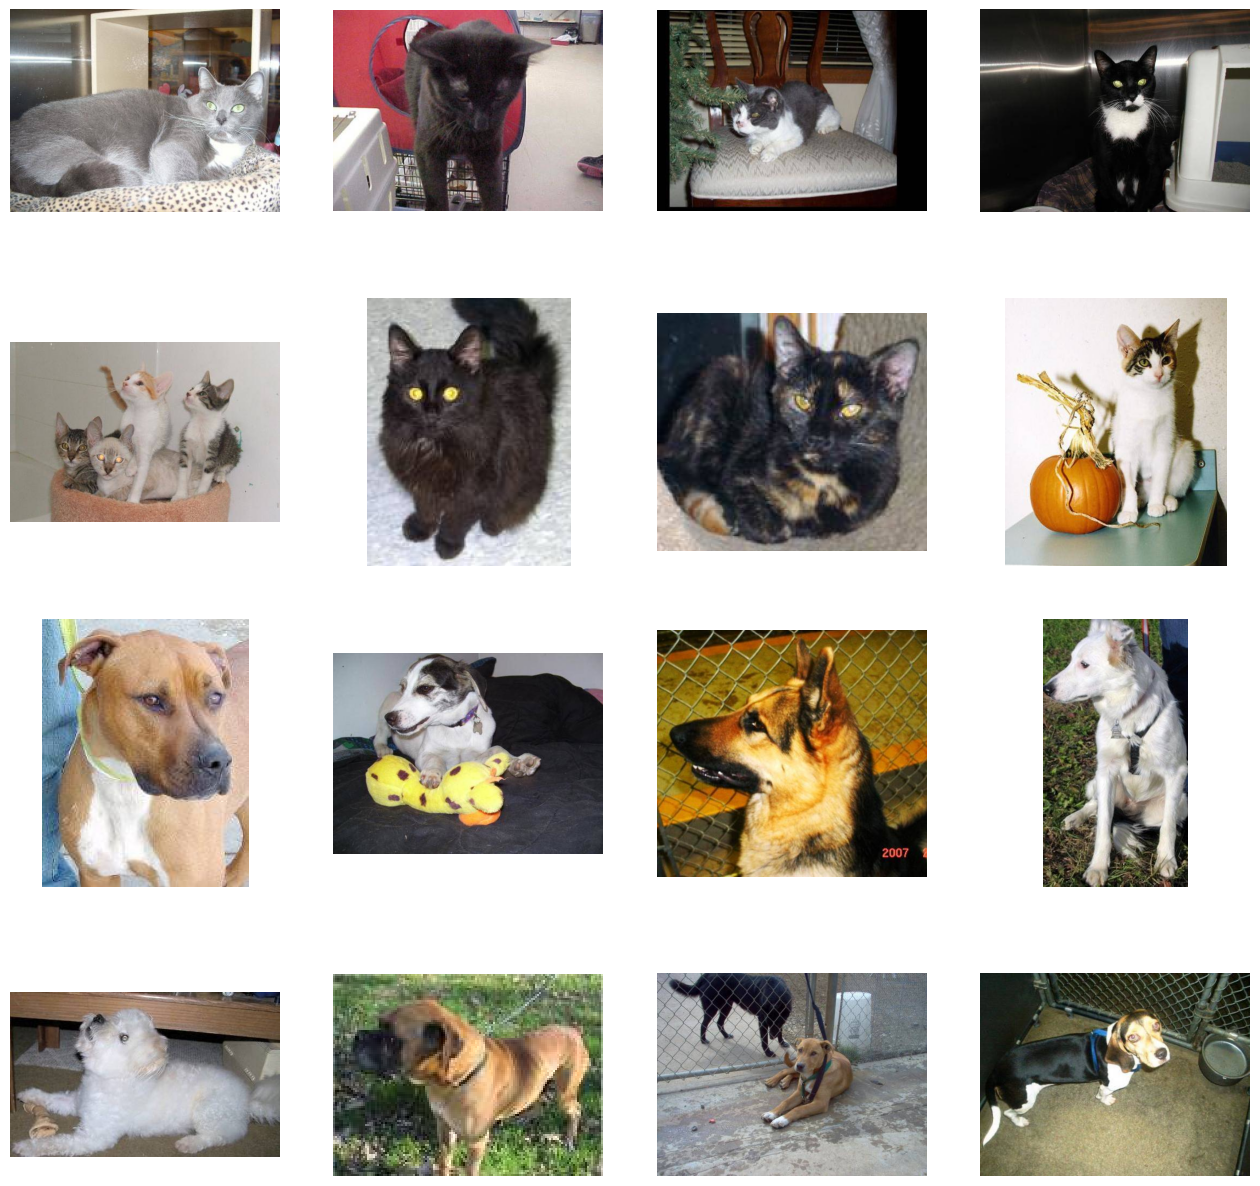

In [8]:
# Configurar o matplotlib fig, e dimensioná-lo para caber em fotos 4x4
fig = plt.gcf()
fig.set_size_inches(ncols *  4, nrows * 4)

pic_index += 8
next_cat_pix = [os.path.join(train_cats_dir, fname)
                for fname in train_cats_fnames[pic_index-8:pic_index]]
next_dog_pix = [os.path.join(train_dogs_dir, fname)
                for fname in train_dogs_fnames[pic_index-8:pic_index]]

for i, img_path in enumerate(next_cat_pix+next_dog_pix):
  # Configurar o subplot, índices do subplot começam em 1
  sp = plt.subplot(nrows, ncols, i + 1)
  sp.axis('Off')  # Não mostrar os eixos ou linhas da grade

  img = mpimg.imread(img_path)
  plt.imshow(img)

plt.show()

# Cosntruindo uma pequena Convnet

In [9]:
# Nosso feature map é 150x150x3: 150x150 para os pixels da imagem e 3 para os canais de cores: R, G e B.
img_input = layers.Input(shape=(150, 150, 3))

# A primeira convolução extrai 16 filtros 3x3
# A convolução é seguida por uma camada de max-pooling com uma janela 2x2
x = layers.Conv2D(16, 3, activation='relu')(img_input)
x = layers.MaxPooling2D(2)(x)

# A segunda convolução extrai 32 filtros 3x3
# A convolução é seguida por uma camada de max-pooling com uma janela 2x2
x = layers.Conv2D(32, 3, activation='relu')(x)
x = layers.MaxPooling2D(2)(x)

# A terceira convolução extrai 64 filtros 3x3
# A convolução é seguida por uma camada de max-pooling com uma janela 2x2
x = layers.Conv2D(64, 3, activation='relu')(x)
x = layers.MaxPooling2D(2)(x)


Após isso, colocarmos duas camadas totalmente conectadas. Como estamos resolvendo um problema de classificação binária (duas classes), terminaremos nossa rede com uma ativação sigmoid para que a saída da rede seja um escalar entre 0 e 1, representando a probabilidade da imagem ser da classe 1 (em oposição à classe 0)

In [10]:
# Achatar o feature map para um tensor de 1 dimensão para que possamos adicionar uma camada completamente conectada
x = layers.Flatten()(x)

# Criar uma camada comlpetamente conectada com uma função de ativação ReLU e 512 neurônios ocultos
x = layers.Dense(512, activation="relu")(x)

# Criar uma camada de saída com um único neurônio e uma função de ativação sigmoid
output = layers.Dense(1, activation="sigmoid")(x)

# Criar o modelo:
# input = feature map
# output = input feature map + stack de convolução/maxpooling + camada completamente conectada + camada de saída sigmoid
model = Model(img_input, output)

Sumarizando a arquitetura:

In [11]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18496)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     9,470,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,494,561 (36.22 MB)

 Trainable params: 9,494,561 (36.22 MB)

 Non-trainable params: 0 (0.00 B)

A coluna output shape mostra a evolução do tamanho do feature map em cada camada sucessiva. As camadas de convolução reduzem um pouco o tamanho dos feature maps devido ao padding, e cada camada de pooling divide pela metade o feature map.

Em seguida, configuraremos as especificações para o treinamento do modelo. Usando a função loss binary_crossentropy, pois é um problema de classificação binária e nossa ativação final é um sigmoid. usaremos o otimizados rmdprop com uma taxa de aprendizado de 0.001. Durante o treinamento, queremos monitorar a acurácia da classificação.

In [13]:
model.compile(loss = 'binary_crossentropy',
              optimizer = RMSprop(learning_rate=0.001),
              metrics = ['acc'])

# Treinando a rede

## Pré-processamento dos dados

Vamos configurar geradores de dados que vão ler as imagens nos diretórios de origem, converter em tensores float32 e alimentar nossa rede. Teremos um gerador para as imagens de treinamento e outro para as imagens de validação.

Normalmente os dados de entrada das redes neurais devem ser normalizados. Neste caso, pré-processaremos as imagens normalizando os valores de pixel para que estejam no intervalo [0, 1] (originalmente todos os valores estão no intervalo [o, 255])

In [15]:
# Todas as imagens serão re-escaladas por 1./255
train_datagen = ImageDataGenerator(rescale= 1./255)
val_datagen = ImageDataGenerator(rescale= 1./255)

# Fluxo de imagens de treinamento em lotes de 20 utilizando o gerador train_datagen
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size = (150, 150),
    batch_size = 20,
    class_mode = 'binary') # usando rótulos binários por usar o binary_crossentropy

# Fluxo de imagens de validação em lotes de 20 utilizando o gerador val_datagen
validation_generator = val_datagen.flow_from_directory(
    validation_dir,
    target_size = (150, 150),
    batch_size = 20,
    class_mode = 'binary')

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


# Treinamento

In [17]:
history = model.fit(
    train_generator,
    steps_per_epoch = 100,  # 2000 imagens = tamanho do lote (20) * passos (100)
    epochs = 15,
    validation_data = validation_generator,
    validation_steps = 50,  # 1000 imagens = tamanho do lote (20) * passos (100)
    verbose = 2)

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


100/100 - 10s - 103ms/step - acc: 0.5205 - loss: 0.7847 - val_acc: 0.5590 - val_loss: 0.6844
Epoch 2/15
100/100 - 5s - 47ms/step - acc: 0.6310 - loss: 0.6625 - val_acc: 0.6020 - val_loss: 0.6764
Epoch 3/15
100/100 - 4s - 43ms/step - acc: 0.6755 - loss: 0.6058 - val_acc: 0.6560 - val_loss: 0.6270
Epoch 4/15
100/100 - 4s - 43ms/step - acc: 0.7080 - loss: 0.5632 - val_acc: 0.7080 - val_loss: 0.5745
Epoch 5/15
100/100 - 5s - 49ms/step - acc: 0.7500 - loss: 0.5096 - val_acc: 0.7110 - val_loss: 0.5960
Epoch 6/15
100/100 - 5s - 54ms/step - acc: 0.7835 - loss: 0.4531 - val_acc: 0.7280 - val_loss: 0.5418
Epoch 7/15
100/100 - 5s - 48ms/step - acc: 0.8295 - loss: 0.3890 - val_acc: 0.7360 - val_loss: 0.5736
Epoch 8/15
100/100 - 4s - 43ms/step - acc: 0.8550 - loss: 0.3261 - val_acc: 0.7370 - val_loss: 0.5848
Epoch 9/15
100/100 - 4s - 42ms/step - acc: 0.8975 - loss: 0.2534 - val_acc: 0.7260 - val_loss: 0.6667
Epoch 10/15
100/100 - 5s - 47ms/step - acc: 0.9355 - loss: 0.1591 - val_acc: 0.7130 - val_l

# Visualizando Representações Intermediárias

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 570ms/step


/tmp/ipython-input-3662949263.py:34: RuntimeWarning: invalid value encountered in divide
  x /= x.std()
/tmp/ipython-input-3662949263.py:37: RuntimeWarning: invalid value encountered in cast
  x = np.clip(x, 0, 255).astype('uint8')


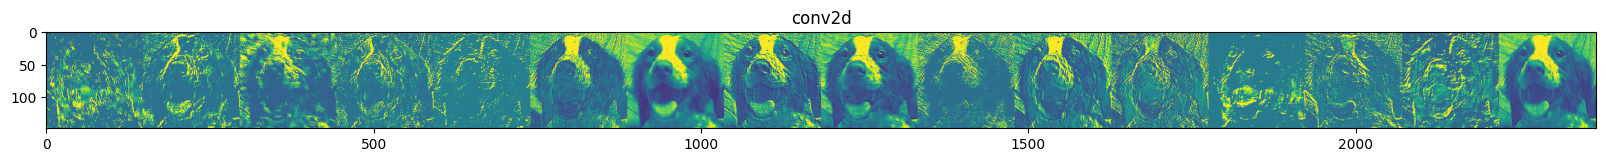

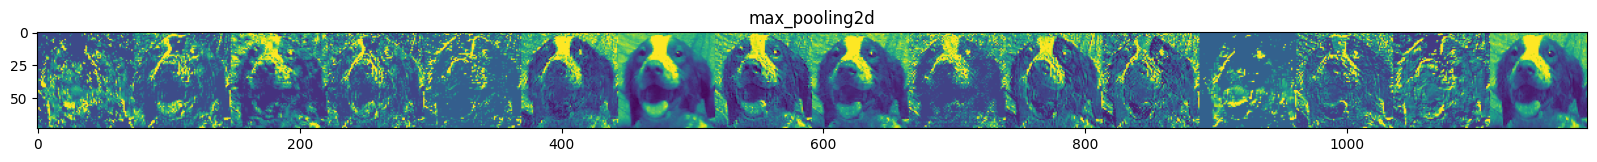

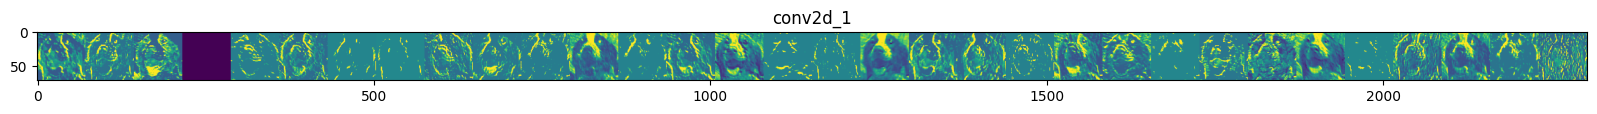

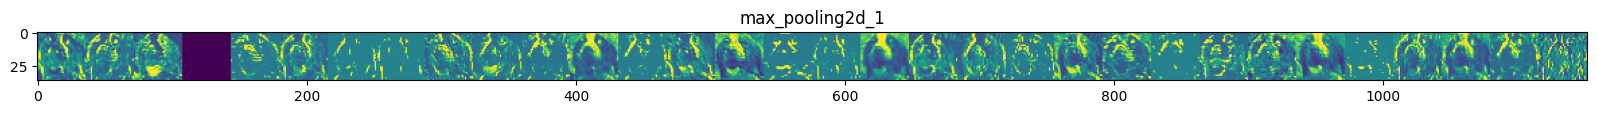

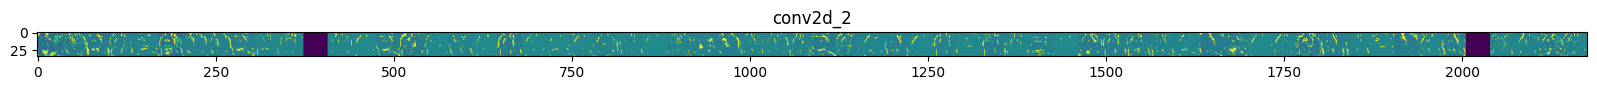

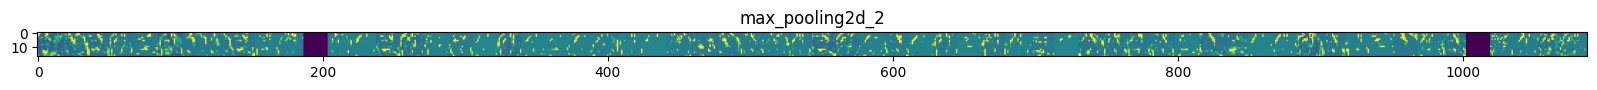

In [24]:
# Vamos definir um novo modelo que receberá as imagens como entrada, e na saída representações intermediárias para todas as camadas no modelo anterior após o primeiro
sucessive_outputs = [layer.output for layer in model.layers[1:]]
visualization_model = Model(img_input, sucessive_outputs)

# Selecionando aleatoriamente uma imagem de entrada de um cão e de um gato do conjunto de treinamento
cat_img_files = [os.path.join(train_cats_dir, f) for f in train_cats_fnames]
dog_img_files = [os.path.join(train_dogs_dir, f) for f in train_dogs_fnames]
img_path = random.choice(cat_img_files + dog_img_files)

img = load_img(img_path, target_size=(150, 150))  # Carregar a imagem e redimensioná-la para 150x150
x = img_to_array(img)  # Converter a imagem em um array numpy
x = x.reshape((1,) + x.shape)  # Adicionar uma dimensão para o lote

# Reescalar por 1/255
x /= 255

# Executando a imagem através da rede, obtendo todas as representações intermediárias para essa imagem
sucessive_feature_maps = visualization_model.predict(x)

# Estes são os nomes das camadas, as quais podem fazer parte do plot
layer_names = [layer.name for layer in model.layers[1:]]

# Agora, vamos mostrar as representações
for layer_name, feature_map in zip(layer_names, sucessive_feature_maps):
  if len(feature_map.shape) == 4:
  # Fazer isso apenas para as camadas convolucionais e maxpool, mas não para as camadas completamente conectadas
    n_features = feature_map.shape[-1]  # Número de características em uma determinada camada
    size = feature_map.shape[1]
    # Colocaremos as imagens nesta matriz
    display_grid = np.zeros((size, size * n_features))
    for i in range(n_features):
      x = feature_map[0, :, :, i]
      x -= x.mean()
      x /= x.std()
      x *= 64
      x += 128
      x = np.clip(x, 0, 255).astype('uint8')
      # Colocaremos cada filtro no grid horizontal
      display_grid[:, i * size : (i + 1) * size] = x
    scale = 20. / n_features
    plt.figure(figsize=(scale * n_features, scale))
    plt.title(layer_name)
    plt.grid(False)
    plt.imshow(display_grid, aspect='auto', cmap='viridis')

# Avaliando os Resultados

Text(0.5, 1.0, 'Loss de treino e validação')

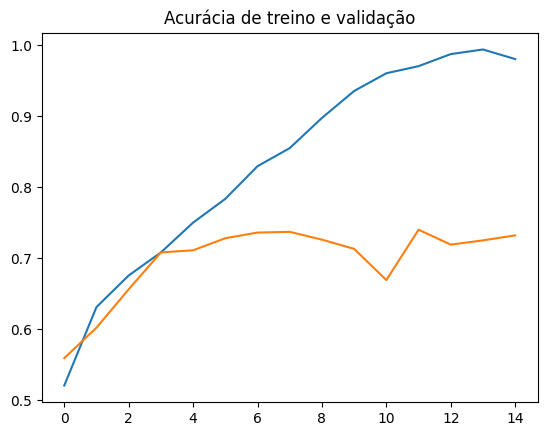

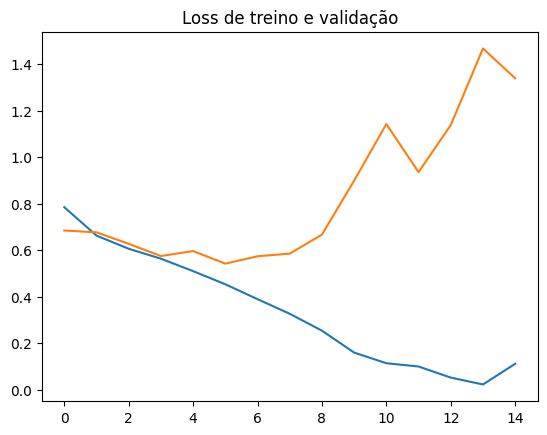

In [25]:
# Recuperar uma lista de resultados de acurácia nos conjuntos de dados de treinamento e validação para cada época de treinamento
acc = history.history['acc']
val_acc = history.history['val_acc']

# Recuperar uma lista de resultados de loss nos conjuntos de dados de treinamento e validação para cada época de treinamento
loss = history.history['loss']
val_loss = history.history['val_loss']

# Pegar o número de épocas
epochs = range(len(acc))

# Plotar a acurácia nos conjuntos de treinamento e validação
plt.plot(epochs, acc)
plt.plot(epochs, val_acc)
plt.title('Acurácia de treino e validação')

plt.figure()

# Plotar a loss de treino e validação de cada época
plt.plot(epochs, loss)
plt.plot(epochs, val_loss)
plt.title('Loss de treino e validação')